# CéphaloAI — Exploration du Dataset CEPHA29
**Insaf Saouiki — EMSI — Stage Cabinet Dr. Redouane Chiguer**

Ce notebook explore le dataset CEPHA29 :
- Structure et format des données
- Visualisation des images et annotations
- Statistiques sur les coordonnées des landmarks
- Vérification de la qualité des données

## 1. Imports et configuration

In [31]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = Path('../data')       # adapte selon ton dossier
RAW_DIR = DATA_DIR / 'raw'
IMG_DIR = RAW_DIR / 'cepha400'
ANN_DIR = RAW_DIR

# Si le dossier d'images n'existe pas, on essaye le dossier cepha400/cepha400
if not IMG_DIR.exists():
    alt_img_dir = RAW_DIR / 'cepha400' / 'cepha400'
    if alt_img_dir.exists():
        IMG_DIR = alt_img_dir

# Si le dossier d'annotations n'existe pas, on essaie le dossier data
if not ANN_DIR.exists():
    alt_ann_dir = DATA_DIR
    if alt_ann_dir.exists():
        ANN_DIR = alt_ann_dir

# Vérification des chemins trouvés
print(f'📁 IMG_DIR utilisé : {IMG_DIR.resolve()} (existe={IMG_DIR.exists()})')
print(f'📁 ANN_DIR utilisé : {ANN_DIR.resolve()} (existe={ANN_DIR.exists()})')

# Les 19 points céphalométriques de Steiner
LANDMARK_NAMES = [
    'S',    # Selle turcique
    'Na',   # Nasion
    'Or',   # Orbitaire
    'Po',   # Porion
    'A',    # Point A
    'B',    # Point B
    'ANS',  # Épine nasale antérieure (ENA)
    'PNS',  # Épine nasale postérieure (ENP)
    'U1T',  # Bord incisif supérieur
    'U1R',  # Apex incisive supérieure
    'L1T',  # Bord incisif inférieur
    'L1R',  # Apex incisive inférieure
    'Pog',  # Pogonion
    'Me',   # Menton
    'Gn',   # Gnathion
    'Go',   # Gonion
    'Ar',   # Articulare
    'Ba',   # Basion
    'D',    # Point D
]

N_LANDMARKS = len(LANDMARK_NAMES)
print(f'✅ Configuration OK — {N_LANDMARKS} landmarks à détecter')
print(f'📁 Dossier data : {DATA_DIR.resolve()}')

📁 IMG_DIR utilisé : C:\Users\inssa\OneDrive\Desktop\CephaloAI\data\raw\cepha400 (existe=True)
📁 ANN_DIR utilisé : C:\Users\inssa\OneDrive\Desktop\CephaloAI\data\raw (existe=True)
✅ Configuration OK — 19 landmarks à détecter
📁 Dossier data : C:\Users\inssa\OneDrive\Desktop\CephaloAI\data


## 2. Exploration de la structure du dataset

In [32]:
# Lister les fichiers disponibles
print('📂 Structure du dataset CEPHA29 :')
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:  # afficher max 5 fichiers par dossier
            print(f'{subindent}{f}')
        if len(files) > 5:
            print(f'{subindent}... ({len(files)} fichiers total)')

📂 Structure du dataset CEPHA29 :
data/
  stats_dimensions.png
  annotations/
  processed/
  raw/
    test1_senior.csv
    test2_senior.csv
    train_senior.csv
    cepha400/


In [33]:
# Charger toutes les annotations
def load_annotations(ann_dir):
    """
    Charge toutes les annotations du dataset CEPHA29.
    Retourne un DataFrame avec les coordonnées de chaque landmark.
    """
    records = []
    ann_path = Path(ann_dir)

    # CEPHA29 peut être en JSON ou en fichiers texte selon la version
    json_files = list(ann_path.glob('*.json'))
    txt_files = list(ann_path.glob('*.txt'))

    if json_files:
        print(f'📄 Format JSON détecté — {len(json_files)} fichiers')
        for f in json_files:
            with open(f) as fp:
                data = json.load(fp)
            record = {'filename': f.stem}
            for i, name in enumerate(LANDMARK_NAMES):
                if str(i) in data:
                    record[f'{name}_x'] = data[str(i)][0]
                    record[f'{name}_y'] = data[str(i)][1]
                elif name in data:
                    record[f'{name}_x'] = data[name][0]
                    record[f'{name}_y'] = data[name][1]
            records.append(record)

    elif txt_files:
        print(f'📄 Format TXT détecté — {len(txt_files)} fichiers')
        for f in txt_files:
            coords = np.loadtxt(f)
            record = {'filename': f.stem}
            for i, name in enumerate(LANDMARK_NAMES):
                if i < len(coords):
                    record[f'{name}_x'] = coords[i][0]
                    record[f'{name}_y'] = coords[i][1]
            records.append(record)

    csv_files = list(ann_path.glob('*.csv'))
    if csv_files and not records:
        print(f'📄 Format CSV détecté — {len(csv_files)} fichiers')
        for f in csv_files:
            df_csv = pd.read_csv(f)
            if 'image_path' in df_csv.columns:
                for _, row in df_csv.iterrows():
                    record = {'filename': Path(str(row['image_path'])).stem}
                    for i, name in enumerate(LANDMARK_NAMES, start=1):
                        x_col = f'{i}_x'
                        y_col = f'{i}_y'
                        if x_col in df_csv.columns and y_col in df_csv.columns:
                            record[f'{name}_x'] = row[x_col]
                            record[f'{name}_y'] = row[y_col]
                    records.append(record)
        if not records:
            print('⚠️ Aucun enregistrement créé depuis le CSV, utilisation du CSV brut.')
            df_csv = pd.read_csv(csv_files[0])
            if 'image_path' in df_csv.columns:
                df_csv['filename'] = df_csv['image_path'].astype(str).map(lambda x: Path(x).stem)
            return df_csv
        df = pd.DataFrame(records)
        print(f'✅ {len(df)} annotations chargées depuis CSV')
        return df

    df = pd.DataFrame(records)
    print(f'✅ {len(df)} annotations chargées')
    return df


df = load_annotations(ANN_DIR)
if 'filename' not in df.columns:
    if 'image_path' in df.columns:
        df['filename'] = df['image_path'].astype(str).map(lambda x: Path(x).stem)
    elif 'image' in df.columns:
        df['filename'] = df['image'].astype(str).map(lambda x: Path(x).stem)
    else:
        raise ValueError("Le DataFrame d'annotations ne contient pas de colonne 'filename', 'image_path' ou 'image'.")

print(f'\n📊 Shape du DataFrame : {df.shape}')
df.head(3)

📄 Format CSV détecté — 3 fichiers
✅ 400 annotations chargées depuis CSV

📊 Shape du DataFrame : (400, 39)


,filename,S_x,S_y,Na_x,Na_y,Or_x,Or_y,Po_x,Po_y,A_x,...,Gn_x,Gn_y,Go_x,Go_y,Ar_x,Ar_y,Ba_x,Ba_y,D_x,D_y
0,289,797,1034,1399,908,1298,1174,588,1245,1483,...,1579,1437,1499,1973,1009,1425,1452,1397,686,1336
1,262,794,1075,1355,1009,1225,1254,596,1261,1363,...,1499,1471,1495,1994,966,1440,1393,1428,690,1322
2,251,698,973,1302,880,1169,1160,505,1160,1375,...,1462,1412,1299,1980,888,1365,1348,1352,574,1280


## 3. Statistiques sur les dimensions des images

🖼️  Nombre total d'images : 400

📐 Dimensions des images (sur 100 échantillons) :
   Largeur  : min=1935, max=1935, moy=1935px
   Hauteur  : min=2400, max=2400, moy=2400px


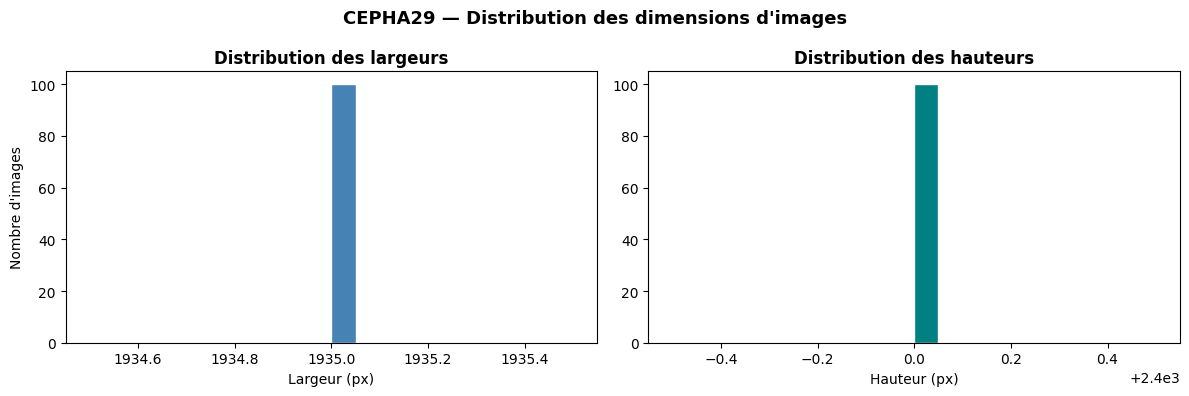

✅ Graphique sauvegardé


In [34]:
# Analyser les dimensions des images
img_files = list(IMG_DIR.glob('*.png')) + list(IMG_DIR.glob('*.jpg')) + list(IMG_DIR.glob('*.bmp'))
print(f'🖼️  Nombre total d\'images : {len(img_files)}')

widths, heights = [], []
for img_path in img_files[:100]:  # analyser les 100 premières
    img = Image.open(img_path)
    widths.append(img.width)
    heights.append(img.height)

print(f'\n📐 Dimensions des images (sur {len(widths)} échantillons) :')
print(f'   Largeur  : min={min(widths)}, max={max(widths)}, moy={np.mean(widths):.0f}px')
print(f'   Hauteur  : min={min(heights)}, max={max(heights)}, moy={np.mean(heights):.0f}px')

# Distribution des dimensions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des largeurs', fontweight='bold')
axes[0].set_xlabel('Largeur (px)')
axes[0].set_ylabel('Nombre d\'images')
axes[1].hist(heights, bins=20, color='teal', edgecolor='white')
axes[1].set_title('Distribution des hauteurs', fontweight='bold')
axes[1].set_xlabel('Hauteur (px)')
plt.suptitle('CEPHA29 — Distribution des dimensions d\'images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/stats_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

## 4. Visualisation d'une image avec ses landmarks

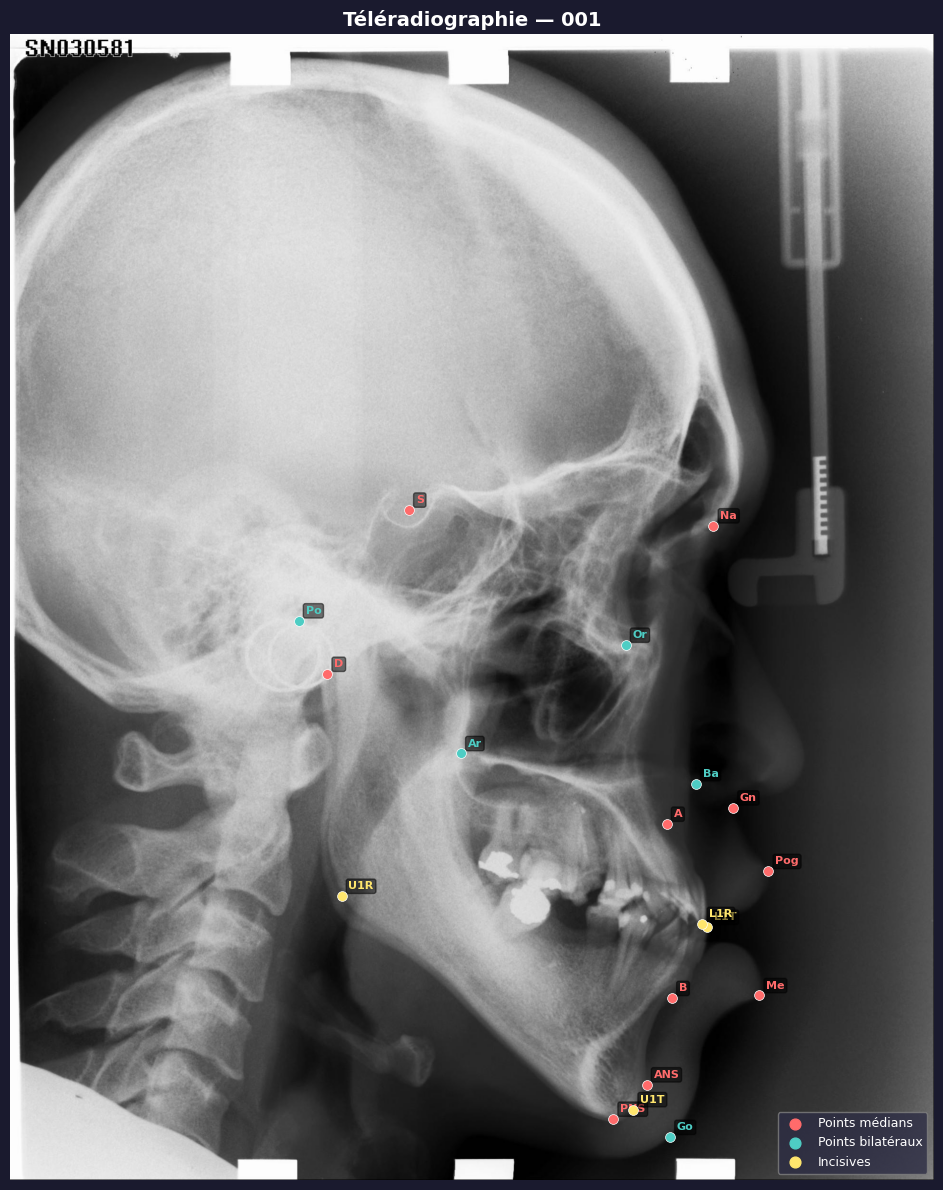

✅ Visualisation de : 001
   19 landmarks annotés sur 19


In [35]:
# Couleurs par groupe de landmarks
LANDMARK_COLORS = {
    'S':   '#FF6B6B',  # rouge
    'Na':  '#FF6B6B',
    'A':   '#FF6B6B',
    'B':   '#FF6B6B',
    'Pog': '#FF6B6B',
    'Me':  '#FF6B6B',
    'Gn':  '#FF6B6B',
    'D':   '#FF6B6B',
    'ANS': '#FF6B6B',
    'PNS': '#FF6B6B',
    'Go':  '#4ECDC4',  # teal — points bilatéraux
    'Po':  '#4ECDC4',
    'Or':  '#4ECDC4',
    'Ar':  '#4ECDC4',
    'Ba':  '#4ECDC4',
    'U1T': '#FFE66D',  # jaune — incisives
    'U1R': '#FFE66D',
    'L1T': '#FFE66D',
    'L1R': '#FFE66D',
}

def visualize_landmarks(img_path, coords_dict, title='Landmarks céphalométriques'):
    """
    Affiche une radio avec ses landmarks annotés.
    coords_dict : {'S': (x,y), 'Na': (x,y), ...}
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 12))
    ax.imshow(img_rgb, cmap='gray')
    
    for name, (x, y) in coords_dict.items():
        color = LANDMARK_COLORS.get(name, '#FFFFFF')
        ax.scatter(x, y, s=50, c=color, zorder=5, edgecolors='white', linewidths=0.5)
        ax.annotate(name, (x, y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, color=color, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    ax.set_title(title, fontsize=14, fontweight='bold', color='white')
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    ax.axis('off')
    
    # Légende
    legend_elements = [
        plt.scatter([], [], c='#FF6B6B', label='Points médians', s=60),
        plt.scatter([], [], c='#4ECDC4', label='Points bilatéraux', s=60),
        plt.scatter([], [], c='#FFE66D', label='Incisives', s=60),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
             facecolor='#2d2d44', edgecolor='gray', labelcolor='white', fontsize=9)
    
    plt.tight_layout()
    return fig

# Visualiser la première image du dataset
sample_img = img_files[0]
sample_name = sample_img.stem

# Récupérer les coordonnées depuis le DataFrame
if sample_name in df['filename'].values:
    row = df[df['filename'] == sample_name].iloc[0]
    coords = {name: (row[f'{name}_x'], row[f'{name}_y']) for name in LANDMARK_NAMES
              if f'{name}_x' in row and not pd.isna(row[f'{name}_x'])}
    fig = visualize_landmarks(sample_img, coords, f'Téléradiographie — {sample_name}')
    plt.savefig('../data/sample_visualization.png', dpi=150, bbox_inches='tight',
                facecolor='#1a1a2e')
    plt.show()
    print(f'✅ Visualisation de : {sample_name}')
    print(f'   {len(coords)} landmarks annotés sur {N_LANDMARKS}')
else:
    print(f'⚠️  Image {sample_name} non trouvée dans les annotations')
    print('   Vérifie que le nom du fichier correspond au fichier annotation')

## 5. Statistiques sur les coordonnées des landmarks

In [36]:
# Statistiques descriptives sur les coordonnées
print('📊 Statistiques des coordonnées X et Y par landmark :\n')

stats_records = []
for name in LANDMARK_NAMES:
    x_col = f'{name}_x'
    y_col = f'{name}_y'
    if x_col in df.columns:
        stats_records.append({
            'Landmark': name,
            'X_mean': df[x_col].mean(),
            'X_std':  df[x_col].std(),
            'Y_mean': df[y_col].mean(),
            'Y_std':  df[y_col].std(),
            'Missing': df[x_col].isna().sum()
        })

stats_df = pd.DataFrame(stats_records)
stats_df = stats_df.round(1)
print(stats_df.to_string(index=False))

# Vérifier les données manquantes
missing = stats_df[stats_df['Missing'] > 0]
if len(missing) > 0:
    print(f'\n⚠️  Données manquantes détectées pour {len(missing)} landmarks')
    print(missing[['Landmark','Missing']])
else:
    print('\n✅ Aucune donnée manquante — dataset complet')

📊 Statistiques des coordonnées X et Y par landmark :

Landmark  X_mean  X_std  Y_mean  Y_std  Missing
       S   814.0   57.0  1041.7   48.5        0
      Na  1395.8   70.6   972.8   69.5        0
      Or  1282.5   62.9  1219.0   64.5        0
      Po   605.6   51.1  1221.6   39.7        0
       A  1395.9   72.8  1528.0   71.5        0
       B  1358.9   87.0  1856.4   82.6        0
     ANS  1347.7  100.2  1987.4   88.3        0
     PNS  1292.2  101.6  2047.8   90.7        0
     U1T  1330.0  101.4  2028.2   90.0        0
     U1R   737.7   66.4  1739.5   71.2        0
     L1T  1424.4   77.7  1697.7   78.4        0
     L1R  1444.1   79.7  1709.0   76.4        0
     Pog  1563.5   75.6  1618.4   83.8        0
      Me  1536.1   85.2  1815.6   84.0        0
      Gn  1505.5   72.4  1499.1   79.0        0
      Go  1437.4  103.8  2030.7  101.6        0
      Ar   977.0   57.5  1432.5   51.3        0
      Ba  1408.3   71.7  1447.9   73.1        0
       D   677.2   52.3  1325.6   

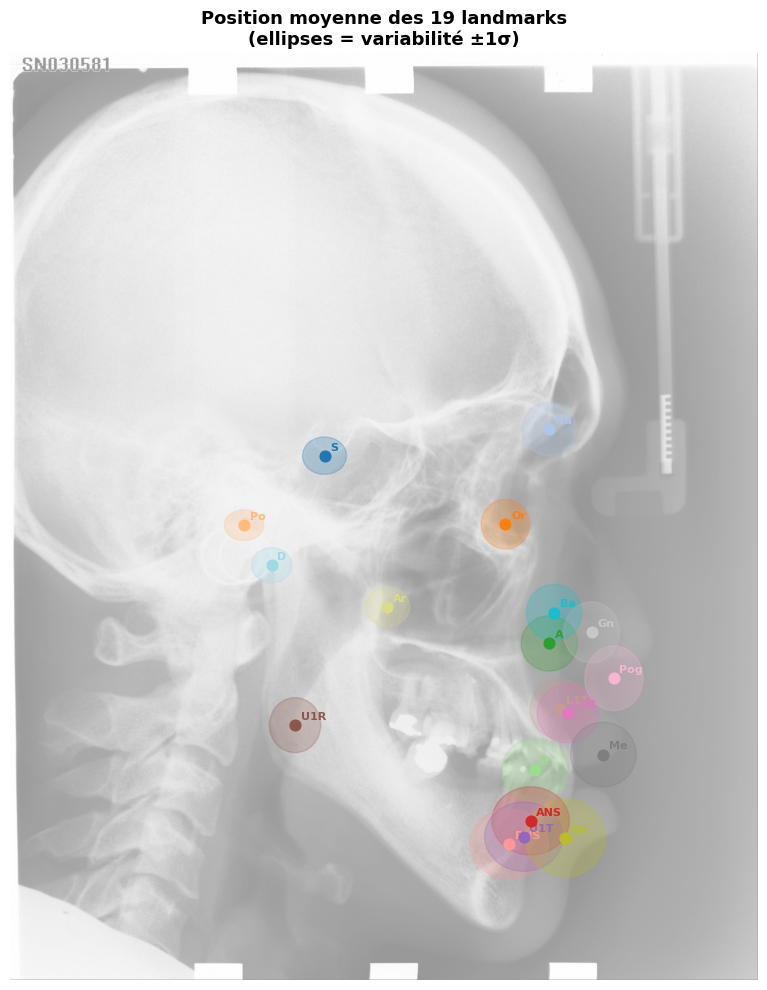

✅ Heatmap des landmarks sauvegardée


In [37]:
# Heatmap de la position moyenne de chaque landmark
# Montre où chaque point se trouve généralement sur les radios

# Prendre une image de référence pour les dimensions
ref_img = cv2.imread(str(img_files[0]), cv2.IMREAD_GRAYSCALE)
h_ref, w_ref = ref_img.shape

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(ref_img, cmap='gray', alpha=0.4)

colors_list = plt.cm.tab20(np.linspace(0, 1, N_LANDMARKS))

for i, name in enumerate(LANDMARK_NAMES):
    x_col = f'{name}_x'
    y_col = f'{name}_y'
    if x_col in df.columns:
        x_mean = df[x_col].mean()
        y_mean = df[y_col].mean()
        x_std  = df[x_col].std()
        y_std  = df[y_col].std()
        
        # Ellipse de variabilité
        ellipse = patches.Ellipse(
            (x_mean, y_mean), width=x_std*2, height=y_std*2,
            color=colors_list[i], alpha=0.25
        )
        ax.add_patch(ellipse)
        ax.scatter(x_mean, y_mean, s=60, c=[colors_list[i]], zorder=5)
        ax.annotate(name, (x_mean, y_mean), xytext=(4,4),
                   textcoords='offset points', fontsize=8, fontweight='bold',
                   color=colors_list[i])

ax.set_title('Position moyenne des 19 landmarks\n(ellipses = variabilité ±1σ)',
            fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/landmarks_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap des landmarks sauvegardée')

## 6. Split Train / Validation / Test

In [38]:
from sklearn.model_selection import train_test_split

# Split : 70% train / 15% val / 15% test
# Seed fixée pour reproductibilité
SEED = 42

all_samples = df['filename'].tolist()
n_total = len(all_samples)

# Premier split : train vs (val + test)
train_files, valtest_files = train_test_split(
    all_samples, test_size=0.30, random_state=SEED
)

# Deuxième split : val vs test
val_files, test_files = train_test_split(
    valtest_files, test_size=0.50, random_state=SEED
)

print('📊 Split du dataset :')
print(f'   Total    : {n_total} images (100%)')
print(f'   Train    : {len(train_files)} images ({len(train_files)/n_total*100:.1f}%)')
print(f'   Val      : {len(val_files)} images ({len(val_files)/n_total*100:.1f}%)')
print(f'   Test     : {len(test_files)} images ({len(test_files)/n_total*100:.1f}%)')

# Sauvegarder les splits
splits = {
    'train': train_files,
    'val':   val_files,
    'test':  test_files
}

with open('../data/splits.json', 'w') as f:
    json.dump(splits, f, indent=2)

print('\n✅ Splits sauvegardés dans data/splits.json')
print('   Ce fichier sera utilisé par preprocessing.py et train.py')

📊 Split du dataset :
   Total    : 400 images (100%)
   Train    : 280 images (70.0%)
   Val      : 60 images (15.0%)
   Test     : 60 images (15.0%)

✅ Splits sauvegardés dans data/splits.json
   Ce fichier sera utilisé par preprocessing.py et train.py


## 7. Résumé final — Bilan de l'exploration

In [ ]:
print('=' * 55)
print('  BILAN EXPLORATION — CEPHA29')
print('=' * 55)
print(f'  Images totales         : {n_total}')
print(f'  Landmarks par image    : {N_LANDMARKS}')
print(f'  Coordonnées totales    : {n_total * N_LANDMARKS * 2}')
print(f'  Train / Val / Test     : {len(train_files)} / {len(val_files)} / {len(test_files)}')
print(f'  Taille cible images    : 512 × 512 px')
print(f'  Sorties modèle         : {N_LANDMARKS * 2} valeurs (x,y × 19)')
print('=' * 55)
print()
print('✅ ÉTAPE 1 TERMINÉE — Prochaine étape : preprocessing.py')
print('   Lance : python src/preprocessing.py')

  BILAN EXPLORATION — CEPHA29
  Images totales         : 400
  Landmarks par image    : 19
  Coordonnées totales    : 15200
  Train / Val / Test     : 280 / 60 / 60
  Taille cible images    : 512 × 512 px
  Sorties modèle         : 38 valeurs (x,y × 19)

✅ ÉTAPE 1 TERMINÉE — Prochaine étape : preprocessing.py
   Lance : python src/preprocessing.py


: 